# Hyperparameter Gridsearch — 2 Giai đoạn
**Kịch bản:** SC1 — CauNoi → CauNoi  
**Lookback / Horizon cố định:** 24h / 12h (tổ hợp có ý nghĩa thực tế nhất)  
**Models:** RNN, LSTM, GRU, CNN-LSTM  

**Giai đoạn 1 — Gridsearch thô:** Tìm `hidden_size` và `num_layers` tốt nhất (epochs ít, nhanh)  
**Giai đoạn 2 — Gridsearch tinh:** Dùng best từ GĐ1, tìm `learning_rate`, `dropout`, `batch_size`


In [4]:
import sys, os, itertools, warnings, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
sys.path.insert(0, os.getcwd())
from models import build_model
warnings.filterwarnings("ignore")

# ── Paths ────────────────────────────────────────────────────────────
DATA_DIR  = Path("data/final_dataset")
OUT_DIR   = Path("outputs/gridsearch")
PLOT_DIR  = OUT_DIR / "plots"
for d in [OUT_DIR, PLOT_DIR]: d.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cuda


## 1. Cấu hình cố định

In [5]:
# ── Cố định trong toàn bộ gridsearch ────────────────────────────────
SCENARIO        = 1
INPUT_STATIONS  = ["CauNoi"]
TARGET_STATION  = "CauNoi"
LOOKBACK        = 12   # 12 bước × 2h = 24h
HORIZON         = 6    # 6 bước × 2h  = 12h

TRAIN_YEARS     = [2020, 2021, 2022]
VAL_YEARS       = [2023]
TEST_YEARS      = [2025]
FEATURE_COLS    = ["wind_speed", "temp", "total_precipitation"]
TEMPORAL_COLS   = ["hour_sin", "hour_cos", "doy_sin", "doy_cos", "month_sin", "month_cos"]
LAG_STEPS       = [6, 12, 24]
MODEL_NAMES     = ["RNN", "LSTM", "GRU", "CNN_LSTM"]

# ── Patience và epochs (dùng chung) ─────────────────────────────────
PATIENCE_COARSE = 8    # Giai đoạn 1: train nhanh
PATIENCE_FINE   = 15   # Giai đoạn 2: train kỹ hơn
EPOCHS_COARSE   = 30
EPOCHS_FINE     = 80


## 2. Hàm tiện ích dữ liệu

In [6]:
def load_station(name):
    return pd.read_csv(DATA_DIR / f"{name}_clean.csv", parse_dates=["Time"])

def split_years(df, years):
    return df[df["Time"].dt.year.isin(years)].copy()

def add_features(df, sal_col):
    df = df.copy()
    hour = df["Time"].dt.hour
    doy  = df["Time"].dt.dayofyear
    mon  = df["Time"].dt.month
    df["hour_sin"]  = np.sin(2 * np.pi * hour / 24)
    df["hour_cos"]  = np.cos(2 * np.pi * hour / 24)
    df["doy_sin"]   = np.sin(2 * np.pi * doy  / 365)
    df["doy_cos"]   = np.cos(2 * np.pi * doy  / 365)
    df["month_sin"] = np.sin(2 * np.pi * mon  / 12)
    df["month_cos"] = np.cos(2 * np.pi * mon  / 12)
    for lag in LAG_STEPS:
        df[f"lag_{lag}"] = df[sal_col].shift(lag)
    return df.dropna().reset_index(drop=True)

def make_windows(features, target, lookback, horizon):
    Xs, ys = [], []
    for i in range(len(features) - lookback - horizon + 1):
        Xs.append(features[i: i+lookback])
        ys.append(target[i+lookback: i+lookback+horizon])
    if not Xs:
        return (np.empty((0,lookback,features.shape[1]),dtype=np.float32),
                np.empty((0,horizon),dtype=np.float32))
    return np.array(Xs, np.float32), np.array(ys, np.float32)

class SalinityDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

def build_loaders(batch_size, lookback=LOOKBACK, horizon=HORIZON):
    """Build train/val/test DataLoaders với batch_size cụ thể."""
    sal_cols     = [f"Salinity_{s}" for s in INPUT_STATIONS]
    target_col   = f"Salinity_{TARGET_STATION}"
    lag_cols     = [f"lag_{k}" for k in LAG_STEPS]
    feature_cols = sal_cols + FEATURE_COLS + TEMPORAL_COLS + lag_cols

    all_data = {s: load_station(s)
                for s in set(INPUT_STATIONS + [TARGET_STATION])}

    loaders, scalers = {}, {}
    scX = scY = None

    for split, years in [("train",TRAIN_YEARS),("val",VAL_YEARS),("test",TEST_YEARS)]:
        split_dfs = {s: split_years(all_data[s], years) for s in all_data}

        dfs = [split_dfs[s][["Time", f"Salinity_{s}"]].copy() for s in INPUT_STATIONS]
        merged = dfs[0]
        for d in dfs[1:]: merged = pd.merge(merged, d, on="Time", how="inner")
        meteo  = split_dfs[INPUT_STATIONS[0]][["Time"] + FEATURE_COLS]
        merged = pd.merge(merged, meteo, on="Time", how="inner")
        if target_col not in merged.columns:
            tgt    = split_dfs[TARGET_STATION][["Time", target_col]]
            merged = pd.merge(merged, tgt, on="Time", how="inner")
        merged = merged.sort_values("Time").reset_index(drop=True)
        merged = add_features(merged, target_col)

        X_raw = merged[feature_cols].values.astype(np.float32)
        y_raw = merged[[target_col]].values.astype(np.float32)

        if split == "train":
            scX = StandardScaler(); scX.fit(X_raw)
            scY = StandardScaler(); scY.fit(y_raw)

        X_sc = scX.transform(X_raw)
        y_sc = scY.transform(y_raw).flatten()

        Xa, ya = [], []
        for yr in sorted(merged["Time"].dt.year.unique()):
            m = merged["Time"].dt.year == yr
            Xw, yw = make_windows(X_sc[m], y_sc[m], lookback, horizon)
            Xa.append(Xw); ya.append(yw)

        X_arr = np.concatenate(Xa); y_arr = np.concatenate(ya)
        shuffle = (split == "train")
        loaders[split] = DataLoader(SalinityDataset(X_arr, y_arr),
                                    batch_size=batch_size, shuffle=shuffle)

    return loaders, scX, scY

# Pre-build loaders với batch=64 để tái sử dụng (batch sẽ rebuild khi cần)
print("Kiểm tra build_loaders...")
_loaders_test, _, _ = build_loaders(64)
input_size = next(iter(_loaders_test["train"]))[0].shape[2]
print(f"✓ Input size: {input_size} features")
print(f"  Train windows: {len(_loaders_test['train'].dataset)}")
print(f"  Val   windows: {len(_loaders_test['val'].dataset)}")
print(f"  Test  windows: {len(_loaders_test['test'].dataset)}")


Kiểm tra build_loaders...
✓ Input size: 13 features
  Train windows: 4814
  Val   windows: 1771
  Test  windows: 1771


## 3. Hàm train và evaluate

In [10]:
def train_one(model, tr_loader, val_loader, lr, epochs, patience):
    model = model.to(DEVICE)
    criterion = nn.MSELoss()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    best_val, pat_cnt, best_state = float("inf"), 0, None
    history = {"train": [], "val": []}

    for epoch in range(1, epochs+1):
        model.train()
        tr_loss = 0.0
        for Xb, yb in tr_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tr_loss += loss.item() * len(Xb)
        tr_loss /= len(tr_loader.dataset)

        model.eval()
        vl_loss = 0.0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                vl_loss += criterion(model(Xb), yb).item() * len(Xb)
        vl_loss /= len(val_loader.dataset)

        history["train"].append(tr_loss); history["val"].append(vl_loss)
        sch.step(vl_loss)

        if vl_loss < best_val:
            best_val  = vl_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            pat_cnt   = 0
        else:
            pat_cnt += 1
            if pat_cnt >= patience: break

    model.load_state_dict(best_state)
    return model, history, best_val

def evaluate_r2(model, loader, scaler_y):
    """Trả về val_R² — dùng làm tiêu chí chọn best hyperparams."""
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            preds.append(model(Xb.to(DEVICE)).cpu().numpy())
            trues.append(yb.numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    pi = scaler_y.inverse_transform(preds.reshape(-1,1)).reshape(preds.shape)
    ti = scaler_y.inverse_transform(trues.reshape(-1,1)).reshape(trues.shape)
    # Non-overlapping để tránh inflate R²
    h   = pi.shape[1]
    idx = np.arange(0, len(pi), h)
    return float(r2_score(ti[idx].flatten(), pi[idx].flatten()))


## 4. Giai đoạn 1 — Gridsearch thô
Tìm `hidden_size` và `num_layers` tốt nhất cho từng model.  
Cố định: `dropout=0.2`, `lr=1e-3`, `batch_size=64`, `epochs=30`


In [5]:
# ── Không gian tìm kiếm GĐ1 ─────────────────────────────────────────
COARSE_GRID = {
    "hidden_size": [64, 128, 256],
    "num_layers" : [1, 2, 3],
}
COARSE_FIXED = {"dropout": 0.2, "lr": 1e-3, "batch_size": 64}

coarse_results = []   # lưu tất cả kết quả
best_coarse    = {}   # {model_name: best_params}

loaders_64, _, scY_64 = build_loaders(COARSE_FIXED["batch_size"])
total_coarse = (len(MODEL_NAMES)
                * len(COARSE_GRID["hidden_size"])
                * len(COARSE_GRID["num_layers"]))
done = 0

print(f"Tổng số thí nghiệm GĐ1: {total_coarse}")
print(f"{'='*70}")

for model_name in MODEL_NAMES:
    best_r2     = -np.inf
    best_params = {}

    print(f"\n▶ Model: {model_name}")
    print(f"  {'hidden':>8} | {'layers':>6} | {'val_R²':>8} | {'time':>6}")
    print(f"  {'-'*40}")

    for hidden, layers in itertools.product(COARSE_GRID["hidden_size"],
                                            COARSE_GRID["num_layers"]):
        t0 = time.time()
        model = build_model(
            model_name, input_size, HORIZON,
            hidden_size=hidden, num_layers=layers,
        )
        # Gán dropout — build_model dùng giá trị mặc định, override thủ công
        for m in model.modules():
            if isinstance(m, nn.Dropout): m.p = COARSE_FIXED["dropout"]

        _, _, _ = train_one(model,
                            loaders_64["train"], loaders_64["val"],
                            lr       = COARSE_FIXED["lr"],
                            epochs   = EPOCHS_COARSE,
                            patience = PATIENCE_COARSE)

        val_r2 = evaluate_r2(model, loaders_64["val"], scY_64)
        elapsed = time.time() - t0
        done += 1

        marker = " ← best" if val_r2 > best_r2 else ""
        print(f"  {hidden:>8} | {layers:>6} | {val_r2:>8.4f} | {elapsed:>5.1f}s{marker}")

        coarse_results.append({
            "model": model_name, "phase": "coarse",
            "hidden_size": hidden, "num_layers": layers,
            **COARSE_FIXED, "val_r2": round(val_r2, 4),
        })

        if val_r2 > best_r2:
            best_r2     = val_r2
            best_params = {"hidden_size": hidden, "num_layers": layers}

    best_coarse[model_name] = {**best_params, **COARSE_FIXED}
    print(f"  → Best: hidden={best_params['hidden_size']}, layers={best_params['num_layers']}, val_R²={best_r2:.4f}")

print(f"\n{'='*70}")
print("Kết quả best GĐ1:")
for m, p in best_coarse.items():
    print(f"  {m:<10}: hidden={p['hidden_size']}, layers={p['num_layers']}")

# Lưu kết quả GĐ1
df_coarse = pd.DataFrame(coarse_results)
df_coarse.to_csv(OUT_DIR / "gridsearch_coarse.csv", index=False)
df_coarse.to_excel(OUT_DIR / "gridsearch_coarse.xlsx", index=False)
print("\n✓ Lưu: outputs/gridsearch/gridsearch_coarse.csv")


Tổng số thí nghiệm GĐ1: 36

▶ Model: RNN
    hidden | layers |   val_R² |   time
  ----------------------------------------
        64 |      1 |   0.8540 |   6.6s ← best
        64 |      2 |   0.8679 |   4.3s ← best
        64 |      3 |   0.8612 |   5.6s
       128 |      1 |   0.8639 |   3.8s
       128 |      2 |   0.8699 |   6.7s ← best
       128 |      3 |   0.8658 |   4.9s
       256 |      1 |   0.8711 |   4.8s ← best
       256 |      2 |   0.8701 |   4.4s
       256 |      3 |   0.8724 |   8.5s ← best
  → Best: hidden=256, layers=3, val_R²=0.8724

▶ Model: LSTM
    hidden | layers |   val_R² |   time
  ----------------------------------------
        64 |      1 |   0.7482 |   7.0s ← best
        64 |      2 |   0.7390 |   7.6s
        64 |      3 |   0.6851 |   5.6s
       128 |      1 |   0.7957 |   6.8s ← best
       128 |      2 |   0.7773 |   6.5s
       128 |      3 |   0.7623 |   9.9s
       256 |      1 |   0.8234 |   6.1s ← best
       256 |      2 |   0.8268 |   8

### 4.1 Visualize kết quả Giai đoạn 1

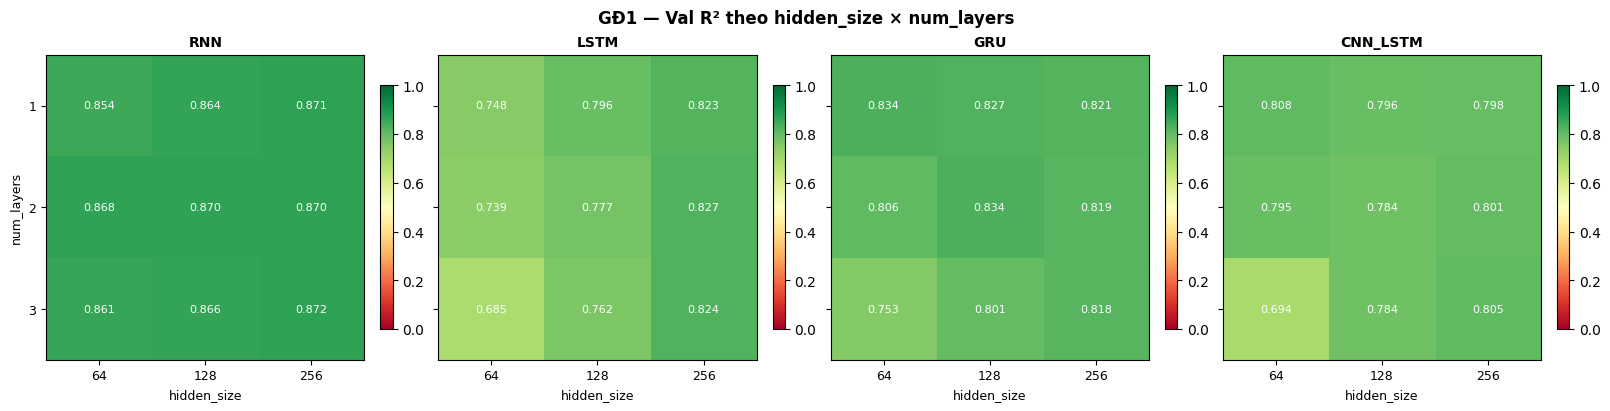

✓ Lưu: outputs/gridsearch/plots/GD1_heatmap.png


In [6]:
df_c = pd.read_csv(OUT_DIR / "gridsearch_coarse.csv")

fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(16, 4),
                         sharey=True, constrained_layout=True)
fig.suptitle("GĐ1 — Val R² theo hidden_size × num_layers", fontsize=12, fontweight="bold")

for ax, mname in zip(axes, MODEL_NAMES):
    sub   = df_c[df_c["model"] == mname]
    pivot = sub.pivot(index="num_layers", columns="hidden_size", values="val_r2")
    im    = ax.imshow(pivot.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, fontsize=9)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    ax.set_xlabel("hidden_size", fontsize=9)
    if ax == axes[0]: ax.set_ylabel("num_layers", fontsize=9)
    ax.set_title(mname, fontsize=10, fontweight="bold")
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            v = pivot.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                        fontsize=8, color="white" if v > 0.6 else "#212121")
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.savefig(PLOT_DIR / "GD1_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()
print("✓ Lưu: outputs/gridsearch/plots/GD1_heatmap.png")


## 5. Giai đoạn 2 — Gridsearch tinh
Dùng `hidden_size` và `num_layers` tốt nhất từ GĐ1.  
Tìm thêm: `learning_rate`, `dropout`, `batch_size`, `epochs=80`


In [7]:
# ── Không gian tìm kiếm GĐ2 ─────────────────────────────────────────
FINE_GRID = {
    "learning_rate": [1e-3, 5e-4, 1e-4],
    "dropout"      : [0.0, 0.2, 0.3],
    "batch_size"   : [32, 64],
}

fine_results = []
best_fine    = {}   # {model_name: best_params}

total_fine = (len(MODEL_NAMES)
              * len(FINE_GRID["learning_rate"])
              * len(FINE_GRID["dropout"])
              * len(FINE_GRID["batch_size"]))

print(f"Tổng số thí nghiệm GĐ2: {total_fine}")
print(f"{'='*70}")

for model_name in MODEL_NAMES:
    best_r2     = -np.inf
    best_params = {}
    base_params = best_coarse[model_name]   # hidden_size, num_layers từ GĐ1

    print(f"\n▶ Model: {model_name}  "
          f"(hidden={base_params['hidden_size']}, layers={base_params['num_layers']})")
    print(f"  {'lr':>8} | {'dropout':>7} | {'batch':>5} | {'val_R²':>8} | {'time':>6}")
    print(f"  {'-'*50}")

    for lr, dropout, batch in itertools.product(
            FINE_GRID["learning_rate"],
            FINE_GRID["dropout"],
            FINE_GRID["batch_size"]):

        t0 = time.time()
        loaders, _, scY_fine = build_loaders(batch)

        model = build_model(
            model_name, input_size, HORIZON,
            hidden_size = base_params["hidden_size"],
            num_layers  = base_params["num_layers"],
        )
        for m in model.modules():
            if isinstance(m, nn.Dropout): m.p = dropout

        _, _, _ = train_one(model,
                            loaders["train"], loaders["val"],
                            lr       = lr,
                            epochs   = EPOCHS_FINE,
                            patience = PATIENCE_FINE)

        val_r2  = evaluate_r2(model, loaders["val"], scY_fine)
        elapsed = time.time() - t0

        marker = " ← best" if val_r2 > best_r2 else ""
        print(f"  {lr:>8} | {dropout:>7} | {batch:>5} | {val_r2:>8.4f} | {elapsed:>5.1f}s{marker}")

        fine_results.append({
            "model"        : model_name, "phase": "fine",
            "hidden_size"  : base_params["hidden_size"],
            "num_layers"   : base_params["num_layers"],
            "learning_rate": lr, "dropout": dropout, "batch_size": batch,
            "val_r2"       : round(val_r2, 4),
        })

        if val_r2 > best_r2:
            best_r2     = val_r2
            best_params = {"learning_rate": lr,
                           "dropout": dropout, "batch_size": batch}

    best_fine[model_name] = {**best_coarse[model_name], **best_params}
    print(f"  → Best: lr={best_params['learning_rate']}, "
          f"dropout={best_params['dropout']}, "
          f"batch={best_params['batch_size']}, val_R²={best_r2:.4f}")

print(f"\n{'='*70}")
print("✅ Kết quả FINAL best params:")
for m, p in best_fine.items():
    print(f"  {m:<10}: {p}")

# Lưu kết quả GĐ2
df_fine = pd.DataFrame(fine_results)
df_fine.to_csv(OUT_DIR / "gridsearch_fine.csv",   index=False)
df_fine.to_excel(OUT_DIR / "gridsearch_fine.xlsx", index=False)

# Lưu best params dạng JSON để dùng lại ở SC notebook
with open(OUT_DIR / "best_params.json", "w") as f:
    json.dump(best_fine, f, indent=2)
print("\n✓ Lưu: outputs/gridsearch/best_params.json")


Tổng số thí nghiệm GĐ2: 72

▶ Model: RNN  (hidden=256, layers=3)
        lr | dropout | batch |   val_R² |   time
  --------------------------------------------------
     0.001 |     0.0 |    32 |   0.8527 |  17.6s ← best
     0.001 |     0.0 |    64 |   0.8633 |  10.7s ← best
     0.001 |     0.2 |    32 |   0.8692 |  16.7s ← best
     0.001 |     0.2 |    64 |   0.8596 |  10.6s
     0.001 |     0.3 |    32 |   0.8633 |  22.1s
     0.001 |     0.3 |    64 |   0.8515 |   9.0s
    0.0005 |     0.0 |    32 |   0.8762 |  18.6s ← best
    0.0005 |     0.0 |    64 |   0.8785 |  12.3s ← best
    0.0005 |     0.2 |    32 |   0.8682 |  15.5s
    0.0005 |     0.2 |    64 |   0.8722 |   9.9s
    0.0005 |     0.3 |    32 |   0.8811 |  18.6s ← best
    0.0005 |     0.3 |    64 |   0.8723 |   9.4s
    0.0001 |     0.0 |    32 |   0.8796 |  17.7s
    0.0001 |     0.0 |    64 |   0.8802 |  16.2s
    0.0001 |     0.2 |    32 |   0.8822 |  36.5s ← best
    0.0001 |     0.2 |    64 |   0.8746 |  15.7s


### 5.1 Visualize kết quả Giai đoạn 2

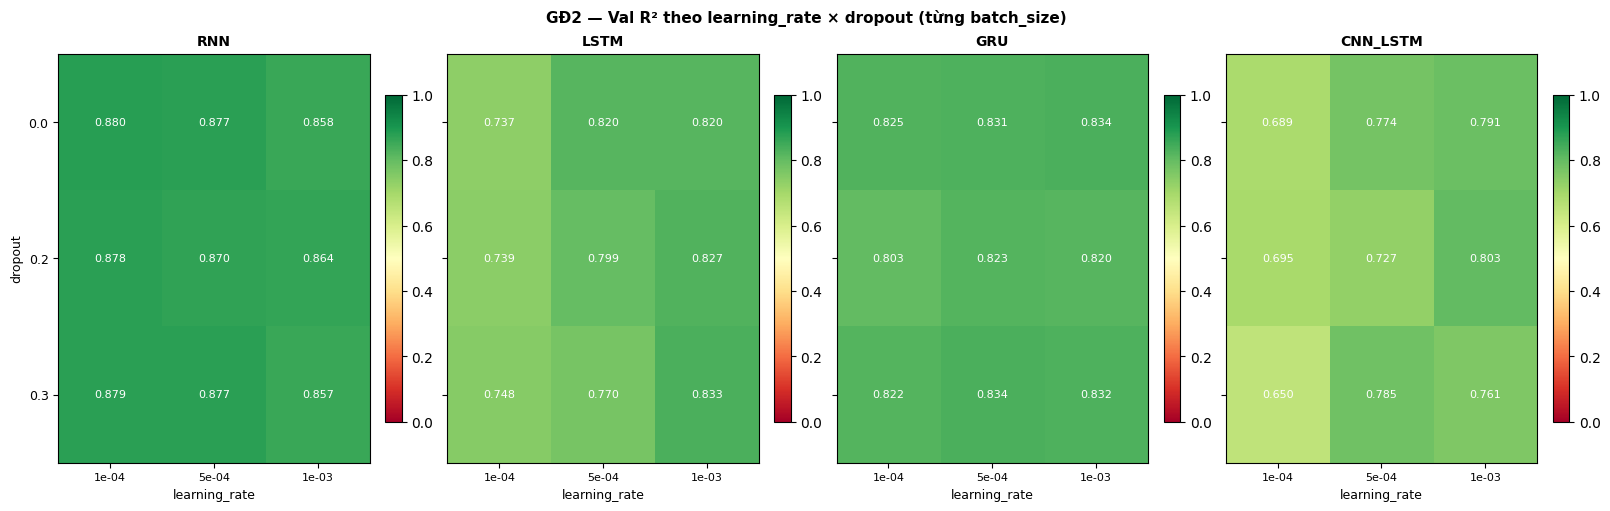

In [8]:
df_f = pd.read_csv(OUT_DIR / "gridsearch_fine.csv")

fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(16, 5),
                         sharey=True, constrained_layout=True)
fig.suptitle("GĐ2 — Val R² theo learning_rate × dropout (từng batch_size)",
             fontsize=11, fontweight="bold")

for ax, mname in zip(axes, MODEL_NAMES):
    sub = df_f[df_f["model"] == mname]
    # Trung bình qua batch_size để heatmap gọn hơn
    piv = sub.groupby(["dropout","learning_rate"])["val_r2"].mean().unstack()
    im  = ax.imshow(piv.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels([f"{v:.0e}" for v in piv.columns], fontsize=8)
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels(piv.index, fontsize=9)
    ax.set_xlabel("learning_rate", fontsize=9)
    if ax == axes[0]: ax.set_ylabel("dropout", fontsize=9)
    ax.set_title(mname, fontsize=10, fontweight="bold")
    for i in range(len(piv.index)):
        for j in range(len(piv.columns)):
            v = piv.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                        fontsize=8, color="white" if v > 0.6 else "#212121")
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.savefig(PLOT_DIR / "GD2_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()


## 6. Tổng hợp & Áp dụng vào SC notebook

In [ ]:
# ── Bảng tổng hợp best params của cả 2 giai đoạn ────────────────────
rows = []
for mname, p in best_fine.items():
    rows.append({"Model": mname, **p})
df_best = pd.DataFrame(rows)
print("="*70)
print("BEST HYPERPARAMETERS SAU 2 GIAI ĐOẠN GRIDSEARCH")
print("="*70)
print(df_best.to_string(index=False))

# So sánh val_R² tốt nhất từng model
print("\nVal R² tốt nhất theo model (GĐ2):")
df_f = pd.read_csv(OUT_DIR / "gridsearch_fine.csv")
for mname in MODEL_NAMES:
    best_r2 = df_f[df_f["model"] == mname]["val_r2"].max()
    print(f"  {mname:<12}: {best_r2:.4f}")

print("""
─────────────────────────────────────────────────────────────
Cách dùng best_params.json trong SC1/SC2/SC3 notebook:

    import json
    with open("outputs/gridsearch/best_params.json") as f:
        BEST_PARAMS = json.load(f)

    # Khi build model:
    p = BEST_PARAMS[model_name]
    model = build_model(
        model_name, input_size, horizon,
        hidden_size = p["hidden_size"],
        num_layers  = p["num_layers"],
    )
    # Khi train:
    train_model(model, tr, val,
                lr         = p["learning_rate"],
                batch_size = p["batch_size"])
─────────────────────────────────────────────────────────────
""")


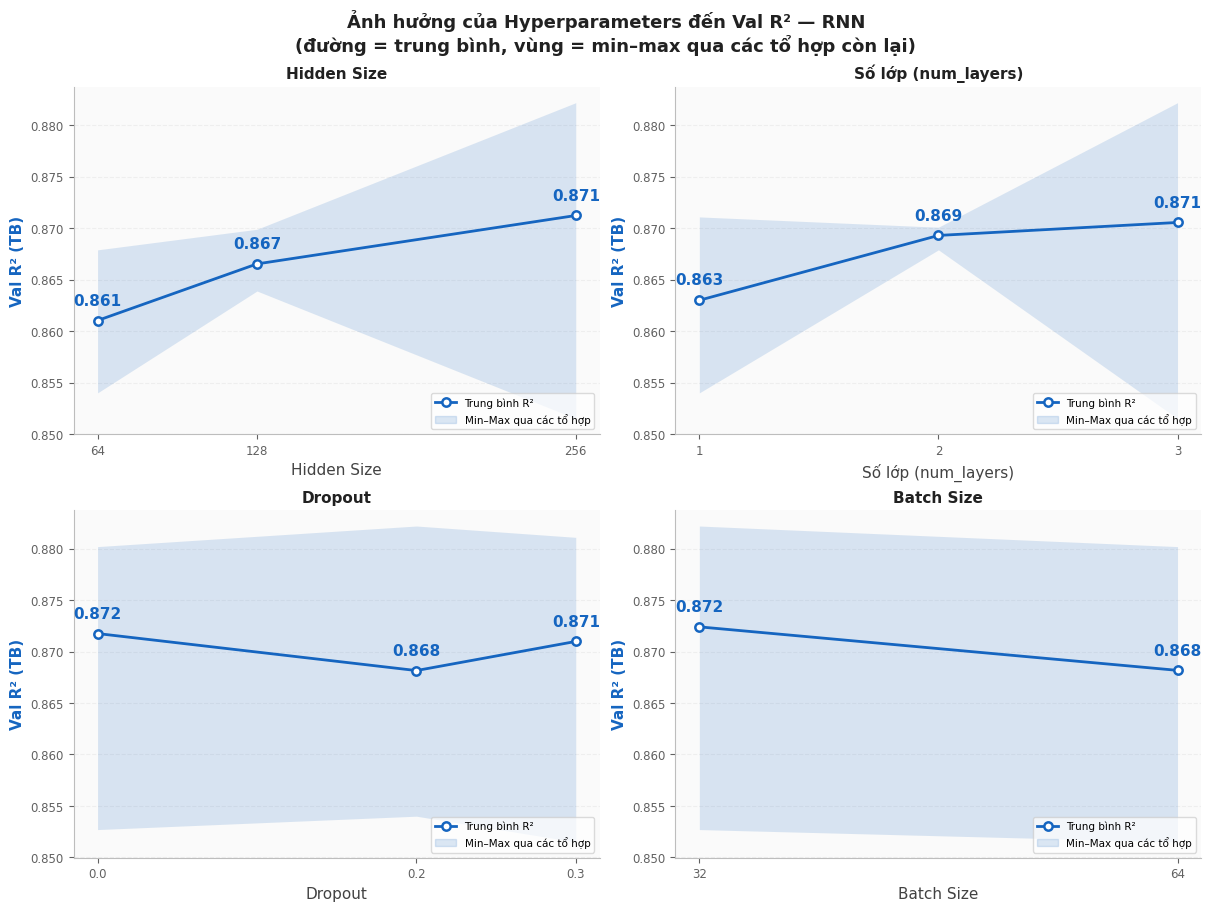

✓ Lưu: outputs/gridsearch/plots/sensitivity_RNN.png


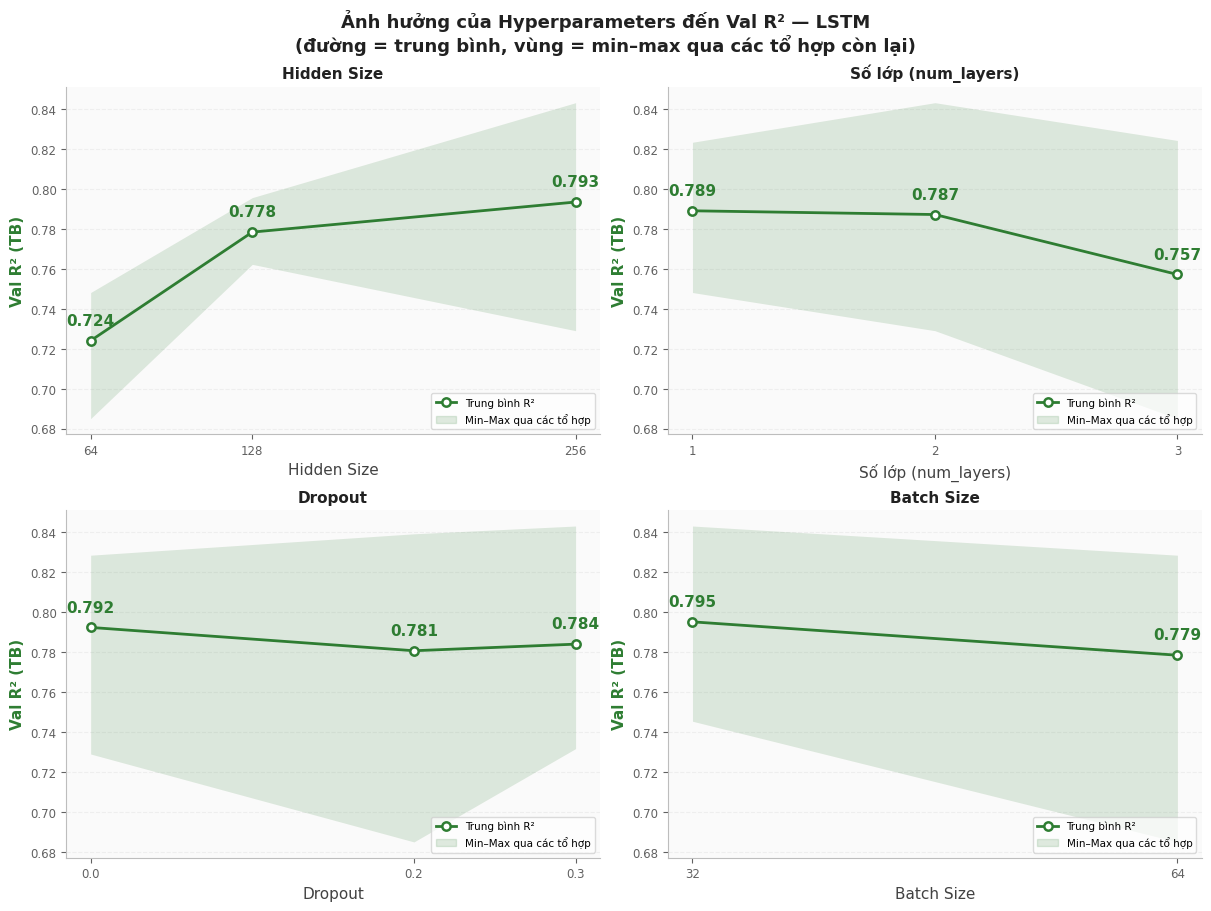

✓ Lưu: outputs/gridsearch/plots/sensitivity_LSTM.png


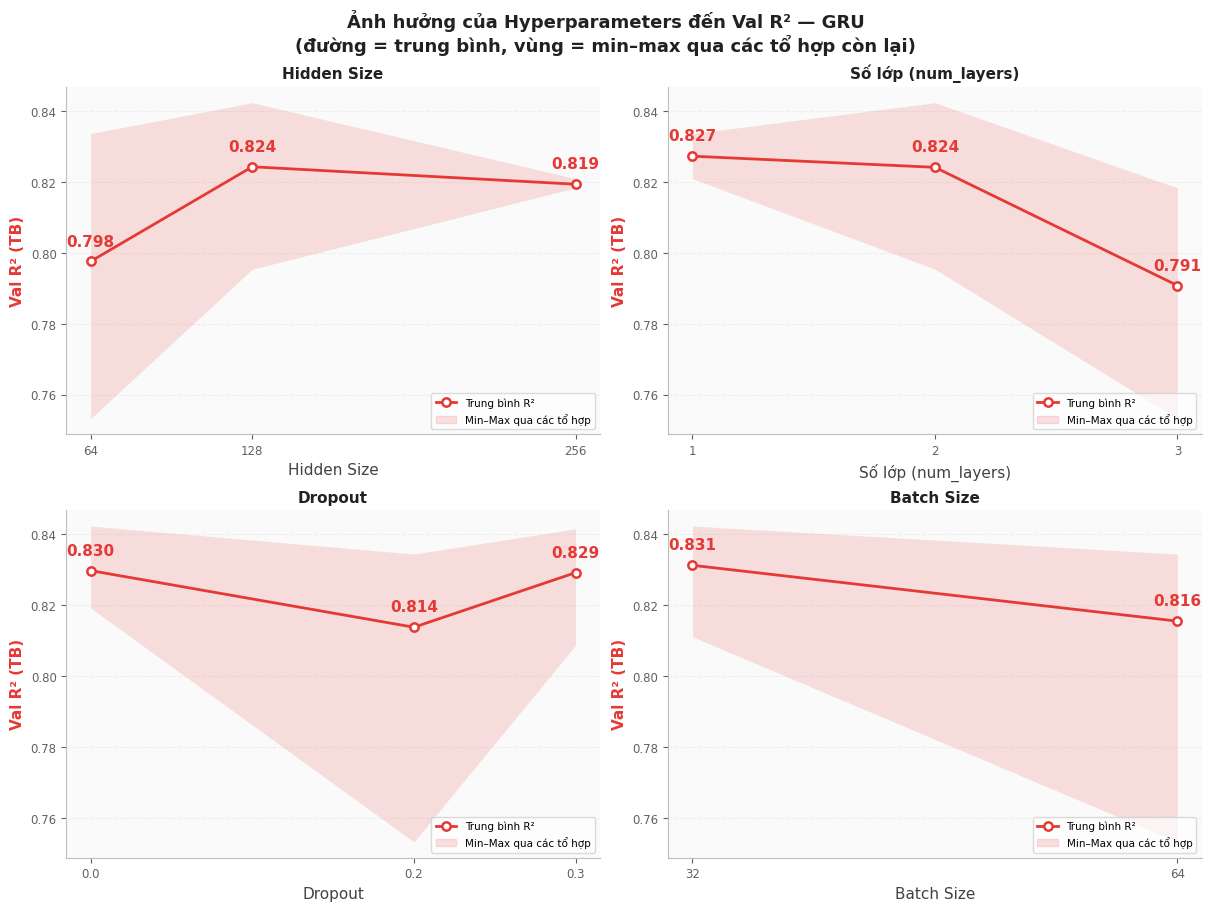

✓ Lưu: outputs/gridsearch/plots/sensitivity_GRU.png


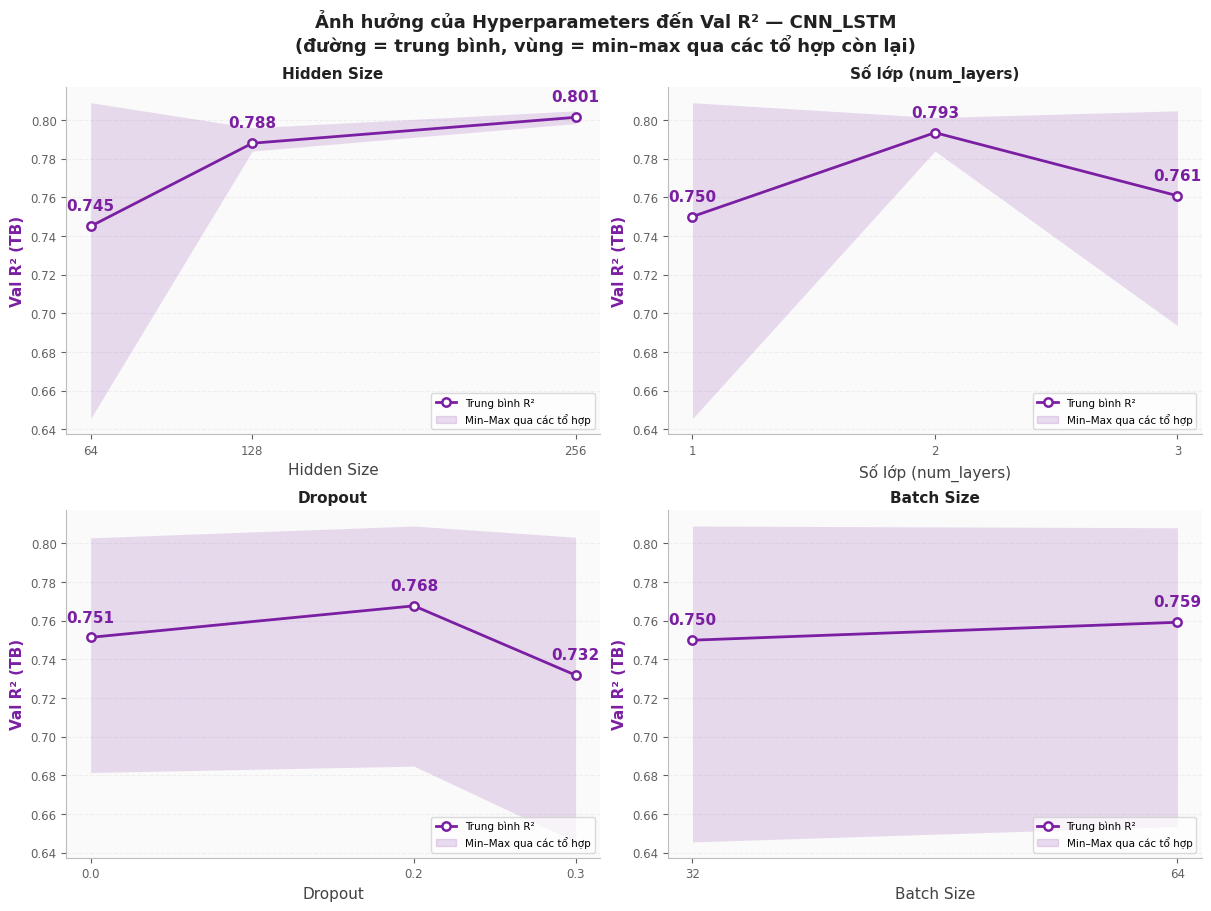

✓ Lưu: outputs/gridsearch/plots/sensitivity_CNN_LSTM.png


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT_DIR  = Path("outputs/gridsearch")
PLOT_DIR = OUT_DIR / "plots"

# ── Load kết quả GĐ1 và GĐ2 ──────────────────────────────────────────
df_coarse = pd.read_csv(OUT_DIR / "gridsearch_coarse.csv")
df_fine   = pd.read_csv(OUT_DIR / "gridsearch_fine.csv")
df        = pd.concat([df_coarse, df_fine], ignore_index=True)
MODEL_NAMES = df["model"].unique().tolist()

PARAMS = ["hidden_size", "num_layers", "dropout", "batch_size"]
COLORS = {"RNN": "#1565C0", "LSTM": "#2E7D32", "GRU": "#E53935", "CNN_LSTM": "#7B1FA2"}
LABELS = {
    "hidden_size": "Hidden Size",
    "num_layers" : "Số lớp (num_layers)",
    "dropout"    : "Dropout",
    "batch_size" : "Batch Size",
}

for model_name in MODEL_NAMES:
    df_m = df[df["model"] == model_name].copy()
    clr  = COLORS.get(model_name, "#1565C0")

    fig, axes = plt.subplots(
        2, 2,
        figsize=(12, 9),
        constrained_layout=True
    )
    fig.suptitle(
        f"Ảnh hưởng của Hyperparameters đến Val R² — {model_name}\n"
        "(đường = trung bình, vùng = min–max qua các tổ hợp còn lại)",
        fontsize=13, fontweight="bold", color="#212121"
    )

    for idx, param in enumerate(PARAMS):
        row_idx = idx // 2
        col_idx = idx %  2
        ax      = axes[row_idx, col_idx]

        grouped = df_m.groupby(param)["val_r2"].agg(["mean", "min", "max"]).reset_index()
        grouped = grouped.sort_values(param)

        x     = grouped[param].values
        ymean = grouped["mean"].values
        ymin  = grouped["min"].values
        ymax  = grouped["max"].values

        # ── Vẽ ────────────────────────────────────────────────────
        ax.fill_between(x, ymin, ymax,
                        color=clr, alpha=0.15, linewidth=0)
        ax.plot(x, ymean,
                color=clr, linewidth=2.0, marker="o",
                markersize=6, markerfacecolor="white",
                markeredgecolor=clr, markeredgewidth=1.8,
                label="Trung bình R²")

        # Annotate giá trị trung bình
        for xi, yi in zip(x, ymean):
            ax.annotate(f"{yi:.3f}",
                        xy=(xi, yi),
                        xytext=(0, 9),
                        textcoords="offset points",
                        ha="center", va="bottom",
                        fontsize=11, color=clr, fontweight="bold")

        # ── Title và labels ────────────────────────────────────────
        ax.set_title(LABELS[param], fontsize=11, fontweight="bold",
                     color="#212121", pad=6)
        ax.set_xlabel(LABELS[param], fontsize=11, color="#424242")
        ax.set_ylabel("Val R² (TB)", fontsize=11, color=clr, fontweight="bold")

        # ── Style ──────────────────────────────────────────────────
        ax.set_xticks(x)
        ax.tick_params(labelsize=8.5, colors="#616161")
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#BDBDBD")
        ax.yaxis.grid(True, color="#EEEEEE", linewidth=0.8, linestyle="--")
        ax.set_axisbelow(True)
        ax.set_facecolor("#FAFAFA")

        # Chú thích vùng confidence band
        ax.fill_between([], [], [],
                        color=clr, alpha=0.15,
                        label="Min–Max qua các tổ hợp")
        ax.legend(fontsize=7.5, framealpha=0.7, loc="lower right")

    plt.savefig(PLOT_DIR / f"sensitivity_{model_name}.png",
                dpi=140, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"✓ Lưu: outputs/gridsearch/plots/sensitivity_{model_name}.png")

In [36]:
BENCH_LOOKBACKS = [3,6,12,24]
BENCH_HORIZONS = [6,12,24]
BENCH_MODEL = "CNN_LSTM"

try:
    import json
    with open(OUT_DIR/ "best_params.json") as f:
        p = json.load(f)[BENCH_MODEL]
    BENCH_HIDDEN = p["hidden_size"]
    BENCH_LAYERS = p["num_layers"]
    BENCH_LR = p["learning_rate"]
    BENCH_BATCH = p["batch_size"]
except:
    BENCH_HIDDEN = 128
    BENCH_LAYERS = 2
    BENCH_LR = 5e-3
    BENCH_BATCH = 32
    print("Can't find the best parameters for model")

BENCH_EPOCHS = 50
BENCH_PATIENCE = 15
print(f"Model: {BENCH_MODEL} | hidden={BENCH_HIDDEN} | layers={BENCH_LAYERS} | lr={BENCH_LR}")
print(f"Tổng thí nghiệm: {len(BENCH_LOOKBACKS) * len(BENCH_HORIZONS)}")

Model: CNN_LSTM | hidden=64 | layers=1 | lr=0.001
Tổng thí nghiệm: 12


In [37]:
bench_results = []
total = len(BENCH_LOOKBACKS) * len(BENCH_HORIZONS)
done  = 0

print(f"{'='*65}")
print(f"  {'Lookback':>10} | {'Horizon':>8} | {'Val R²':>8} | {'Val MSE':>10} | time")
print(f"  {'-'*65}")

for lb, hz in itertools.product(BENCH_LOOKBACKS, BENCH_HORIZONS):
    t0 = time.time()
    loaders, _, scY = build_loaders(BENCH_BATCH, lookback=lb, horizon=hz)

    if any(len(loaders[k].dataset) == 0 for k in ["train","val","test"]):
        print(f"  {lb*2:>8}h | {hz*2:>6}h | SKIP")
        continue
    model = build_model(BENCH_MODEL, input_size, hz, hidden_size=BENCH_HIDDEN, num_layers=BENCH_LAYERS)

    model, _, best_val_loss = train_one(model, loaders["train"], loaders["val"], lr = BENCH_LR, epochs=BENCH_EPOCHS, patience=BENCH_PATIENCE)

    model.eval()
    preds_v, trues_v = [], []
    with torch.no_grad():
        for Xb, yb in loaders["val"]:
            preds_v.append(model(Xb.to(DEVICE)).cpu().numpy())
            trues_v.append(yb.numpy())
    pv = np.concatenate(preds_v)
    tv = np.concatenate(trues_v)
    pv_inv = scY.inverse_transform(pv.reshape(-1,1)).reshape(pv.shape)
    tv_inv = scY.inverse_transform(tv.reshape(-1,1)).reshape(tv.shape)

    # Non-overlapping để tránh inflate
    idx    = np.arange(0, len(pv_inv), hz)
    flat_p = pv_inv[idx].flatten()
    flat_t = tv_inv[idx].flatten()

    val_r2  = float(r2_score(flat_t, flat_p))
    val_mse = float(mean_squared_error(flat_t, flat_p))
    elapsed = time.time() - t0
    done   += 1

    print(f"  {lb*2:>8}h | {hz*2:>6}h | {val_r2:>8.4f} | {val_mse:>10.4f} | {elapsed:.1f}s  [{done}/{total}]")

    bench_results.append({
        "lookback_steps": lb,  "horizon_steps": hz,
        "lookback_h"    : lb*2, "horizon_h"    : hz*2,
        "val_r2"        : round(val_r2,  4),
        "val_mse"       : round(val_mse, 4),
    })

print(f"{'='*65}")
df_bench = pd.DataFrame(bench_results)
df_bench.to_csv(OUT_DIR  / "bench_lookback_CNN_LSTM.csv",   index=False)
print(f"\n✓ Lưu: outputs/gridsearch/bench_lookback.csv")

    Lookback |  Horizon |   Val R² |    Val MSE | time
  -----------------------------------------------------------------
         6h |     12h |   0.7592 |     1.0951 | 30.4s  [1/12]
         6h |     24h |   0.7202 |     1.2385 | 24.4s  [2/12]
         6h |     48h |   0.6174 |     1.6936 | 21.4s  [3/12]
        12h |     12h |   0.8091 |     0.8659 | 16.5s  [4/12]
        12h |     24h |   0.7696 |     1.0314 | 18.0s  [5/12]
        12h |     48h |   0.6829 |     1.4195 | 19.8s  [6/12]
        24h |     12h |   0.7307 |     1.2098 | 19.1s  [7/12]
        24h |     24h |   0.7248 |     1.2361 | 16.6s  [8/12]
        24h |     48h |   0.6378 |     1.6273 | 23.5s  [9/12]
        48h |     12h |   0.7915 |     0.9221 | 19.7s  [10/12]
        48h |     24h |   0.7707 |     1.0142 | 18.0s  [11/12]
        48h |     48h |   0.6075 |     1.6705 | 21.8s  [12/12]

✓ Lưu: outputs/gridsearch/bench_lookback.csv


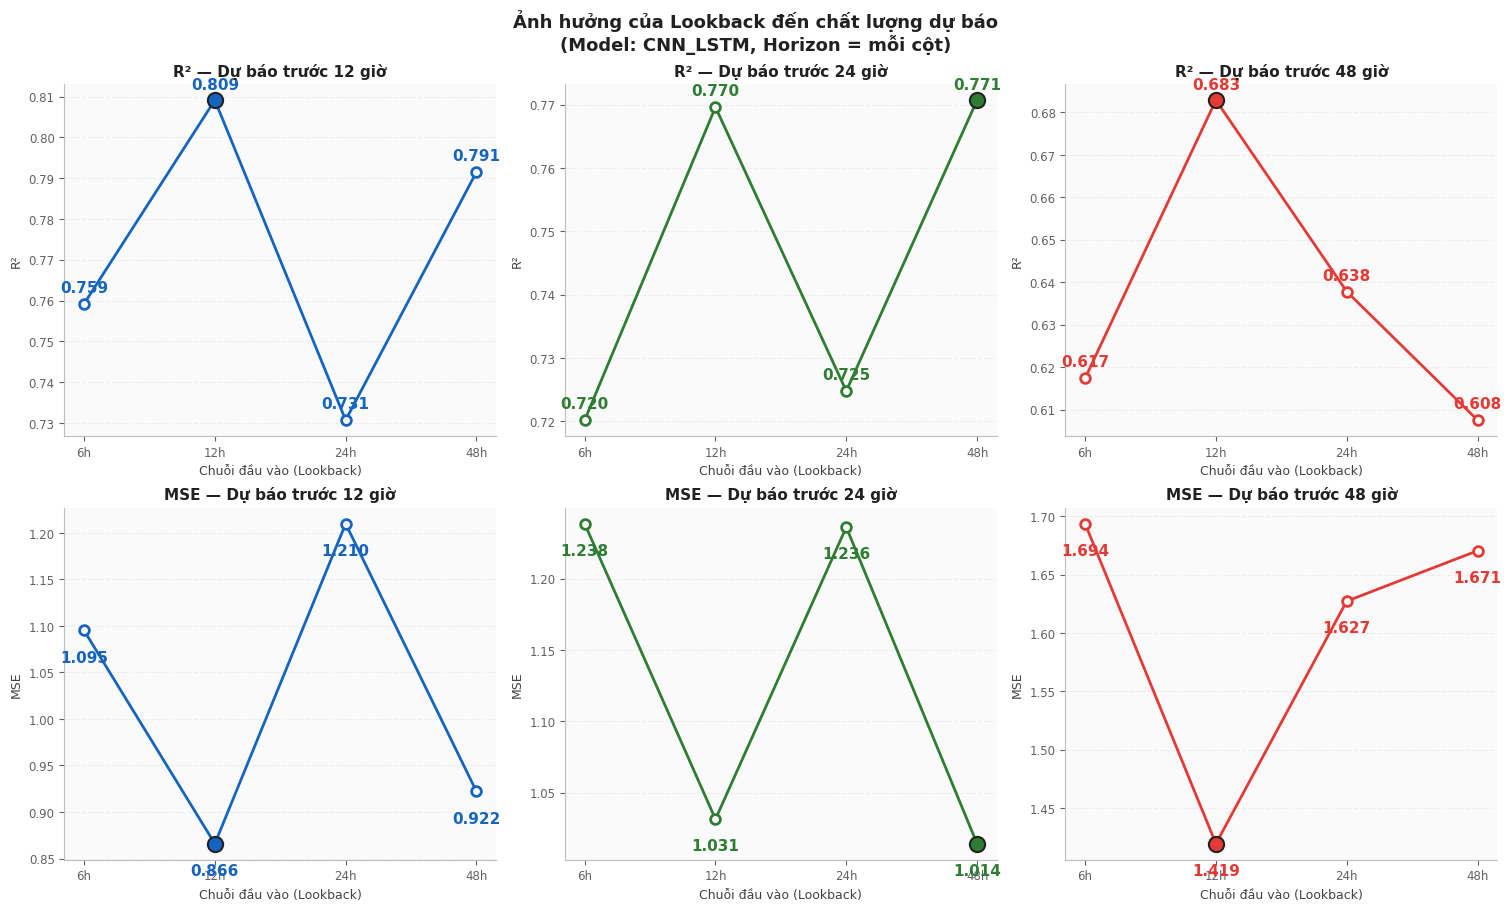

✓ Lưu: outputs/gridsearch/plots/bench_lookback_horizon_GRU.png


In [38]:
df_b    = pd.read_csv(OUT_DIR / "bench_lookback_CNN_LSTM.csv")
HORIZONS_H  = sorted(df_b["horizon_h"].unique())
LOOKBACKS_H = sorted(df_b["lookback_h"].unique())
METRICS     = [("val_r2", "R²"), ("val_mse", "MSE")]

# Layout: 2 hàng (R² trên, MSE dưới) × N cột (mỗi horizon 1 cột)
n_rows = len(METRICS)
n_cols = len(HORIZONS_H)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 4.5 * n_rows),
    constrained_layout=True,
)
fig.suptitle(
    f"Ảnh hưởng của Lookback đến chất lượng dự báo\n"
    f"(Model: {BENCH_MODEL}, Horizon = mỗi cột)",
    fontsize=13, fontweight="bold", color="#212121",
)

COLORS_HZ = {
    HORIZONS_H[0]: "#1565C0",
    HORIZONS_H[1]: "#2E7D32",
    HORIZONS_H[2]: "#E53935",
} if len(HORIZONS_H) >= 3 else {h:"#1565C0" for h in HORIZONS_H}

X_LABELS = [f"{h}h" for h in LOOKBACKS_H]

for col_idx, hz_h in enumerate(HORIZONS_H):
    sub = df_b[df_b["horizon_h"] == hz_h].sort_values("lookback_h")
    clr = COLORS_HZ.get(hz_h, "#1565C0")

    for row_idx, (metric_col, metric_label) in enumerate(METRICS):
        ax = axes[row_idx, col_idx]
        y  = sub[metric_col].values
        x  = np.arange(len(LOOKBACKS_H))

        # ── Đường chính ────────────────────────────────────────
        ax.plot(x, y,
                color=clr, linewidth=2.0,
                marker="o", markersize=7,
                markerfacecolor="white",
                markeredgecolor=clr, markeredgewidth=2.0)

        # Annotate giá trị
        for xi, yi in zip(x, y):
            offset = 6 if metric_col == "val_r2" else -14
            va     = "bottom" if metric_col == "val_r2" else "top"
            ax.annotate(f"{yi:.3f}",
                        xy=(xi, yi), xytext=(0, offset),
                        textcoords="offset points",
                        ha="center", va=va,
                        fontsize=11, color=clr, fontweight="bold")

        # Highlight điểm tốt nhất
        best_idx = y.argmin() if metric_col == "val_mse" else y.argmax()
        ax.scatter(x[best_idx], y[best_idx],
                   s=120, zorder=5,
                   facecolors=clr, edgecolors="#212121",
                   linewidths=1.5)

        # ── Title và labels ────────────────────────────────────
        if row_idx == 0:
            ax.set_title(f"{metric_label} — Dự báo trước {hz_h} giờ",
                         fontsize=11, fontweight="bold", color="#212121", pad=6)
        else:
            ax.set_title(f"{metric_label} — Dự báo trước {hz_h} giờ",
                         fontsize=11, fontweight="bold", color="#212121", pad=6)

        ax.set_xlabel("Chuỗi đầu vào (Lookback)", fontsize=9, color="#424242")
        ax.set_ylabel(metric_label, fontsize=9, color="#424242")
        ax.set_xticks(x)
        ax.set_xticklabels(X_LABELS, fontsize=9)
        ax.tick_params(colors="#616161", labelsize=8.5)
        ax.spines[["top","right"]].set_visible(False)
        ax.spines[["left","bottom"]].set_color("#BDBDBD")
        ax.yaxis.grid(True, color="#EEEEEE", linewidth=0.8, linestyle="--")
        ax.set_axisbelow(True)
        ax.set_facecolor("#FAFAFA")

plt.savefig(PLOT_DIR / "bench_lookback_horizon_CNN_LSTM.png",
            dpi=140, bbox_inches="tight", facecolor="white")
plt.show()
print("✓ Lưu: outputs/gridsearch/plots/bench_lookback_horizon_GRU.png")


In [ ]:
BENCH_CNN_MODEL = "CNN_LSTM"

try:
    with open(r"C:\Users\HP\Desktop\Đồ án\src\src_code\outputs\gridsearch\best_params.json") as f:
        _p = json.load(f)[BENCH_CNN_MODEL]
    CNN_HIDDEN  = 64
    CNN_LAYERS  = 1
    CNN_LR      = 0.0001
    CNN_DROPOUT = 0.2
    CNN_BATCH   = 32
    print(f"✓ Loaded best params: {_p}")
except Exception as e:
    # Fallback nếu chưa có best_params.json
    CNN_HIDDEN  = 64
    CNN_LAYERS  = 1
    CNN_LR      = 1e-3
    CNN_DROPOUT = 0.2
    CNN_BATCH   = 32
    print(f"⚠ Không tìm thấy best_params.json, dùng default: {e}")

# ── Search space ─────────────────────────────────────────────────────
CNN_FILTERS_GRID = [32, 64, 128]
KERNEL_SIZE_GRID = [2, 3, 5, 7]
BENCH_LOOKBACKS  = [12]
BENCH_HORIZONS   = [12]

CNN_BENCH_EPOCHS   = 50
CNN_BENCH_PATIENCE = 15

total_exp = (len(CNN_FILTERS_GRID) * len(KERNEL_SIZE_GRID)
             * len(BENCH_LOOKBACKS) * len(BENCH_HORIZONS))

print(f"\nModel: {BENCH_CNN_MODEL}")
print(f"  hidden={CNN_HIDDEN}, layers={CNN_LAYERS}, lr={CNN_LR}, "
      f"dropout={CNN_DROPOUT}, batch={CNN_BATCH}")
print(f"  filters: {CNN_FILTERS_GRID}")
print(f"  kernel:  {KERNEL_SIZE_GRID}")
print(f"  lookbacks (steps): {BENCH_LOOKBACKS}  →  (hours): {[l*2 for l in BENCH_LOOKBACKS]}")
print(f"  horizons  (steps): {BENCH_HORIZONS}   →  (hours): {[h*2 for h in BENCH_HORIZONS]}")
print(f"  Tổng thí nghiệm: {total_exp}")

# ── Chạy benchmark ──────────────────────────────────────────────────
cnn_bench_results = []
done = 0

print(f"\n{'='*80}")
print(f"  {'filters':>8} | {'kernel':>6} | {'LB(h)':>6} | {'HZ(h)':>6} | "
      f"{'Val R²':>8} | {'Val MSE':>10} | time")
print(f"  {'-'*80}")

for lb in BENCH_LOOKBACKS:
    for hz in BENCH_HORIZONS:
        # Build loaders 1 lần cho mỗi cặp (lb, hz)
        loaders, _, scY = build_loaders(CNN_BATCH, lookback=lb, horizon=hz)

        if any(len(loaders[k].dataset) == 0 for k in ["train", "val", "test"]):
            print(f"  {'---':>8} | {'---':>6} | {lb*2:>6} | {hz*2:>6} | SKIP (empty dataset)")
            continue

        for filters, kernel in itertools.product(CNN_FILTERS_GRID, KERNEL_SIZE_GRID):
            # Bỏ qua nếu kernel_size > lookback (Conv1D không hợp lệ)
            if kernel > lb:
                done += 1
                continue

            t0 = time.time()

            # Build model với cnn_filters và kernel_size
            model = build_model(
                BENCH_CNN_MODEL, input_size, hz,
                hidden_size  = CNN_HIDDEN,
                num_layers   = CNN_LAYERS,
                cnn_filters  = filters,
                kernel_size  = kernel,
            )
            # Override dropout
            for m in model.modules():
                if isinstance(m, nn.Dropout):
                    m.p = CNN_DROPOUT

            model, _, _ = train_one(
                model, loaders["train"], loaders["val"],
                lr       = CNN_LR,
                epochs   = CNN_BENCH_EPOCHS,
                patience = CNN_BENCH_PATIENCE,
            )

            # ── Evaluate ─────────────────────────────────────────
            model.eval()
            preds_v, trues_v = [], []
            with torch.no_grad():
                for Xb, yb in loaders["val"]:
                    preds_v.append(model(Xb.to(DEVICE)).cpu().numpy())
                    trues_v.append(yb.numpy())
            pv = np.concatenate(preds_v)
            tv = np.concatenate(trues_v)
            pv_inv = scY.inverse_transform(pv.reshape(-1, 1)).reshape(pv.shape)
            tv_inv = scY.inverse_transform(tv.reshape(-1, 1)).reshape(tv.shape)

            # Non-overlapping
            idx    = np.arange(0, len(pv_inv), hz)
            flat_p = pv_inv[idx].flatten()
            flat_t = tv_inv[idx].flatten()

            val_r2  = float(r2_score(flat_t, flat_p))
            val_mse = float(mean_squared_error(flat_t, flat_p))
            elapsed = time.time() - t0
            done += 1

            print(f"  {filters:>8} | {kernel:>6} | {lb*2:>6} | {hz*2:>6} | "
                  f"{val_r2:>8.4f} | {val_mse:>10.4f} | {elapsed:.1f}s  [{done}/{total_exp}]")

            cnn_bench_results.append({
                "cnn_filters"   : filters,
                "kernel_size"   : kernel,
                "lookback_steps": lb,
                "horizon_steps" : hz,
                "lookback_h"    : lb * 2,
                "horizon_h"     : hz * 2,
                "val_r2"        : round(val_r2, 4),
                "val_mse"       : round(val_mse, 4),
            })

print(f"{'='*80}")

# ── Lưu kết quả ─────────────────────────────────────────────────────
df_cnn_bench = pd.DataFrame(cnn_bench_results)
df_cnn_bench.to_csv(OUT_DIR / "bench_cnn_filters_kernel.csv", index=False)
df_cnn_bench.to_excel(OUT_DIR / "bench_cnn_filters_kernel.xlsx", index=False)
print(f"\n✓ Lưu: outputs/gridsearch/bench_cnn_filters_kernel.csv")
print(f"✓ Tổng kết quả: {len(df_cnn_bench)} thí nghiệm")

# ── In bảng best filter×kernel cho mỗi cặp (lookback, horizon) ──────
print(f"\n{'='*80}")
print("BEST cnn_filters × kernel_size cho từng (lookback, horizon):")
print(f"{'='*80}")
for (lb_h, hz_h), grp in df_cnn_bench.groupby(["lookback_h", "horizon_h"]):
    best = grp.loc[grp["val_r2"].idxmax()]
    print(f"  LB={int(lb_h):>3}h, HZ={int(hz_h):>3}h  →  "
          f"filters={int(best['cnn_filters'])}, kernel={int(best['kernel_size'])}, "
          f"R²={best['val_r2']:.4f}, MSE={best['val_mse']:.4f}")

✓ Loaded best params: {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'learning_rate': 0.001}

Model: CNN_LSTM
  hidden=64, layers=1, lr=0.0001, dropout=0.2, batch=32
  filters: [32, 64, 128]
  kernel:  [2, 3, 5, 7]
  lookbacks (steps): [3, 6, 12, 24]  →  (hours): [6, 12, 24, 48]
  horizons  (steps): [6, 12, 24]   →  (hours): [12, 24, 48]
  Tổng thí nghiệm: 144

   filters | kernel |  LB(h) |  HZ(h) |   Val R² |    Val MSE | time
  --------------------------------------------------------------------------------
        32 |      2 |      6 |     12 |   0.6663 |     1.5174 | 42.5s  [1/144]
        32 |      3 |      6 |     12 |   0.6860 |     1.4280 | 40.0s  [2/144]


KeyboardInterrupt: 